2025/10/08 11:28:22 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing Decision Tree using PSO...


2025/10/08 11:28:26 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.62657 seconds
2025/10/08 11:28:29 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.69652 seconds
2025/10/08 11:28:31 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.28858 seconds
2025/10/08 11:28:34 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.59422 seconds
2025/10/08 11:28:36 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.28263 seconds
2025/10/08 11:28:36 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

PSO Accuracy: 0.6870
PSO Best Params: {'max_depth': 19, 'min_samples_split': 18}

Optimizing Decision Tree using GA...


2025/10/08 11:28:40 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.6801744210607404, Global best: -0.6801744210607404, Runtime: 1.74879 seconds
2025/10/08 11:28:42 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.6801744210607404, Global best: -0.6801744210607404, Runtime: 2.39569 seconds
2025/10/08 11:28:44 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.6838124383413225, Global best: -0.6838124383413225, Runtime: 2.36988 seconds
2025/10/08 11:28:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.6838124383413225, Global best: -0.6838124383413225, Runtime: 2.52815 seconds
2025/10/08 11:28:49 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.6838124383413225, Global best: -0.6838124383413225, Runtime: 2.51003 seconds
2025/10/08 11:28:49 PM, INFO, mealpy.swarm_based.BA.OriginalBA: Origin

GA Accuracy: 0.6838
GA Best Params: {'max_depth': 17, 'min_samples_split': 13}

Optimizing Decision Tree using Bat...


2025/10/08 11:28:54 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 2.71677 seconds
2025/10/08 11:28:57 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 2.96887 seconds
2025/10/08 11:29:00 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 2.99997 seconds
2025/10/08 11:29:03 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 3.15580 seconds
2025/10/08 11:29:06 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 3.21849 seconds


Bat Accuracy: 0.6925
Bat Best Params: {'max_depth': 20, 'min_samples_split': 19}



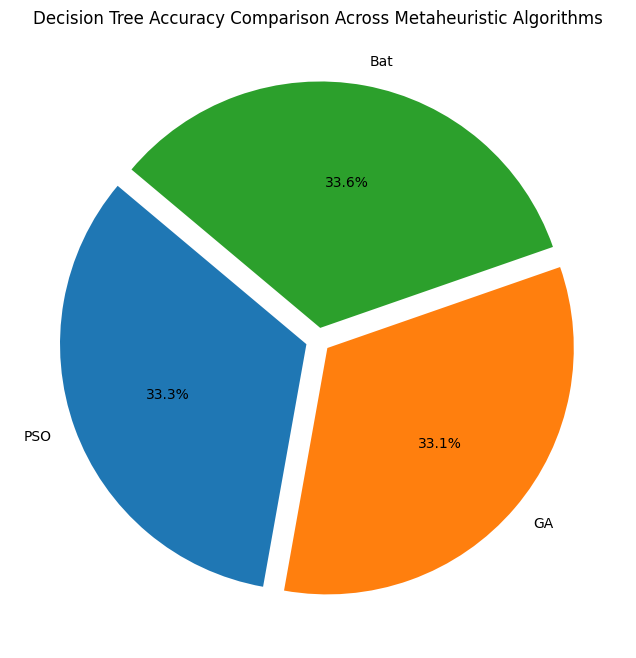

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Decision Tree Objective Function
# ----------------------------
def dt_objective_function(solution):
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])
    
    try:
        if max_depth < 1:
            max_depth = None
        if min_samples_split < 2:
            min_samples_split = 2
            
        dt = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Minimize negative accuracy
    except:
        fitness = 1.0
    
    return fitness

# ----------------------------
# Decision Tree Problem Definition
# ----------------------------
dt_problem = {
    "bounds": [
        FloatVar(lb=1, ub=20, name="max_depth"),              # Max depth
        FloatVar(lb=2, ub=20, name="min_samples_split")       # Min samples to split
    ],
    "minmax": "min",
    "obj_func": dt_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Decision Tree using {name}...")
    best_agent = optimizer.solve(dt_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'max_depth': int(best_solution[0]),
        'min_samples_split': int(best_solution[1])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Decision Tree Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()


2025/10/09 12:56:35 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing Decision Tree using PSO...


2025/10/09 12:56:47 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7111118566064555, Global best: -0.7111118566064555, Runtime: 6.81127 seconds
2025/10/09 12:56:54 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7111118566064555, Global best: -0.7111118566064555, Runtime: 6.60423 seconds
2025/10/09 12:56:59 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 5.76417 seconds
2025/10/09 12:57:07 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 7.14541 seconds
2025/10/09 12:57:13 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 6.53489 seconds
2025/10/09 12:57:13 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

PSO Accuracy: 0.7116
PSO Best Params: {'max_depth': 27, 'min_samples_split': 4, 'min_samples_leaf': 3, 'criterion': 'gini'}

Optimizing Decision Tree using GA...


2025/10/09 12:57:21 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7088349895754901, Global best: -0.7088349895754901, Runtime: 4.08561 seconds
2025/10/09 12:57:27 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 5.86731 seconds
2025/10/09 12:57:34 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 6.94552 seconds
2025/10/09 12:57:41 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 7.02161 seconds
2025/10/09 12:57:47 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 6.34361 seconds
2025/10/09 12:57:47 AM, INFO, mealpy.swarm_based.BA.OriginalBA: Origin

...

Cuckoo Accuracy: 0.7175
Cuckoo Best Params: {'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 3, 'criterion': 'gini'}

Optimizing Decision Tree using Firefly...


2025/10/09 01:03:50 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 62.09922 seconds
2025/10/09 01:05:19 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 89.07165 seconds
2025/10/09 01:06:13 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 53.77656 seconds
2025/10/09 01:07:06 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 53.39542 seconds
2025/10/09 01:08:01 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 54.85447 seconds
2025/10/09 01:08:01 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalABC(ep

Firefly Accuracy: 0.7116
Firefly Best Params: {'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 3, 'criterion': 'gini'}

Optimizing Decision Tree using ABC...


2025/10/09 01:08:10 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.7129283802622653, Global best: -0.7129283802622653, Runtime: 6.48499 seconds
2025/10/09 01:08:17 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.7129283802622653, Global best: -0.7129283802622653, Runtime: 7.02710 seconds
2025/10/09 01:08:24 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.7147486313947969, Global best: -0.7147486313947969, Runtime: 7.13328 seconds
2025/10/09 01:08:32 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.7165688825273286, Global best: -0.7165688825273286, Runtime: 7.51192 seconds
2025/10/09 01:08:39 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.7165688825273286, Global best: -0.7165688825273286, Runtime: 7.38343 seconds


ABC Accuracy: 0.7166
ABC Best Params: {'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 3, 'criterion': 'gini'}



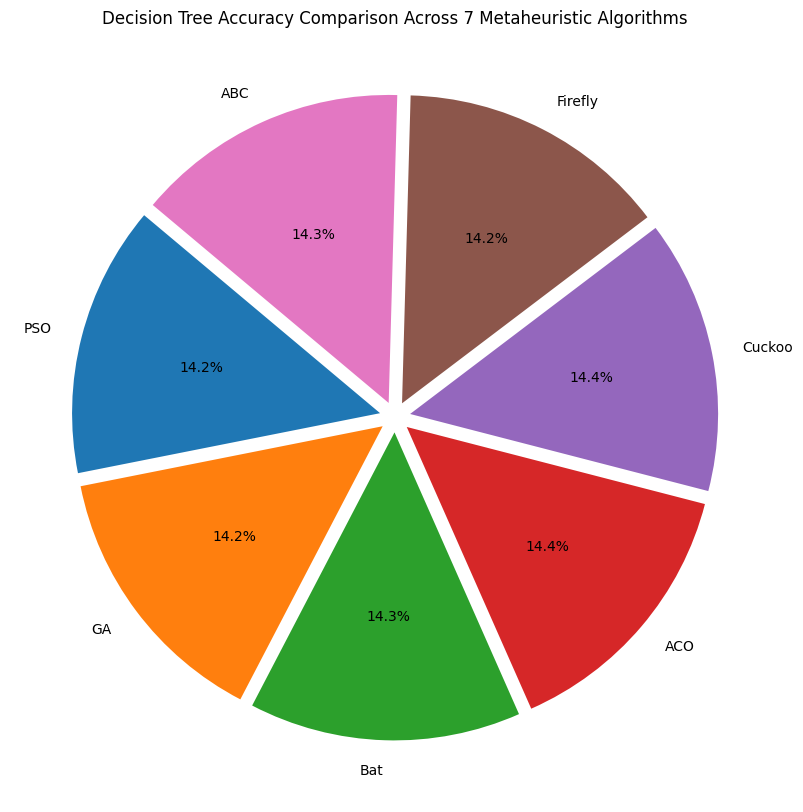

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import warnings

# ----------------------------
# Mealpy algorithm imports (latest structure)
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Decision Tree Objective Function
# ----------------------------
def dt_objective_function(solution):
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])
    min_samples_leaf = int(solution[2])
    criterion_idx = int(solution[3])
    criterion = 'gini' if criterion_idx == 0 else 'entropy'
    
    try:
        dt = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth if max_depth > 0 else None,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# Decision Tree Problem Definition
# ----------------------------
dt_problem = {
    "bounds": [
        FloatVar(lb=2, ub=30, name="max_depth"),
        FloatVar(lb=2, ub=10, name="min_samples_split"),
        FloatVar(lb=1, ub=5, name="min_samples_leaf"),
        FloatVar(lb=0, ub=1, name="criterion")   # 0=gini, 1=entropy
    ],
    "minmax": "min",
    "obj_func": dt_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Decision Tree using {name}...")
    best_agent = optimizer.solve(dt_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    criterion = 'gini' if int(best_solution[3]) == 0 else 'entropy'
    best_params = {
        'max_depth': int(best_solution[0]),
        'min_samples_split': int(best_solution[1]),
        'min_samples_leaf': int(best_solution[2]),
        'criterion': criterion
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Pie Chart
# ----------------------------
plt.figure(figsize=(10, 10))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Decision Tree Accuracy Comparison Across 7 Metaheuristic Algorithms")
plt.show()


In [1]:
from mealpy.swarm_based import CSO
print(dir(CSO))


['Agent', 'Optimizer', 'OriginalCSO', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np']


In [ ]:
# ===============================================
#   BERT + Metaheuristic Optimization + Decision Tree
# ===============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import warnings
import torch
from transformers import BertTokenizer, BertModel

# ----------------------------
# Mealpy algorithm imports
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')

# ======================================================
# STEP 1: Load dataset + Use BERT for vectorization
# ======================================================
def load_data_with_bert():
    # Load datasets
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0).reset_index(drop=True)
    
    # Load pre-trained BERT model and tokenizer
    tokenizer = BertTokenizer.from_pretrained('distilbert-base-uncased')
    model = BertModel.from_pretrained('distilbert-base-uncased')

    # Function to generate sentence embeddings using BERT
    def get_bert_embeddings(texts, batch_size=16):
        embeddings = []
        model.eval()
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = texts[i:i+batch_size]
                encoded = tokenizer(
                    batch, padding=True, truncation=True,
                    max_length=128, return_tensors='pt'
                )
                outputs = model(**encoded)
                # Mean pooling of last hidden states
                batch_embeddings = outputs.last_hidden_state.mean(dim=1)
                embeddings.append(batch_embeddings)
        return torch.cat(embeddings).numpy()

    print("🔄 Generating BERT embeddings... (This may take 3–5 minutes)")
    X = get_bert_embeddings(df["text"].tolist())
    y = df["label"].values

    print("✅ BERT embeddings generated successfully!")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test


# ======================================================
# STEP 2: Load Data
# ======================================================
X_train, X_test, y_train, y_test = load_data_with_bert()


# ======================================================
# STEP 3: Objective Function for Decision Tree
# ======================================================
def dt_objective_function(solution):
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])
    min_samples_leaf = int(solution[2])
    criterion_idx = int(solution[3])
    criterion = 'gini' if criterion_idx == 0 else 'entropy'
    
    try:
        dt = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth if max_depth > 0 else None,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Negative because Mealpy minimizes
    except:
        fitness = 1.0
    return fitness


# ======================================================
# STEP 4: Define Optimization Problem
# ======================================================
dt_problem = {
    "bounds": [
        FloatVar(lb=2, ub=30, name="max_depth"),
        FloatVar(lb=2, ub=10, name="min_samples_split"),
        FloatVar(lb=1, ub=5, name="min_samples_leaf"),
        FloatVar(lb=0, ub=1, name="criterion")   # 0=gini, 1=entropy
    ],
    "minmax": "min",
    "obj_func": dt_objective_function
}


# ======================================================
# STEP 5: Run All Metaheuristic Algorithms
# ======================================================
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"\n🚀 Optimizing Decision Tree using {name}...")
    best_agent = optimizer.solve(dt_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness  # convert back to positive accuracy
    
    criterion = 'gini' if int(best_solution[3]) == 0 else 'entropy'
    best_params = {
        'max_depth': int(best_solution[0]),
        'min_samples_split': int(best_solution[1]),
        'min_samples_leaf': int(best_solution[2]),
        'criterion': criterion
    }
    
    results[name] = best_fitness
    print(f"✅ {name} Accuracy: {best_fitness:.4f}")
    print(f"🏆 {name} Best Params: {best_params}\n")


# ======================================================
# STEP 6: Visualization (Pie Chart)
# ======================================================
plt.figure(figsize=(10, 10))
plt.pie(
    results.values(), labels=results.keys(),
    autopct='%1.1f%%', startangle=140,
    explode=[0.05]*len(results)
)
plt.title("Decision Tree Accuracy Comparison Across 7 Metaheuristic Algorithms (BERT)")
plt.show()


 Using device: cpu
🔄 Generating new BERT embeddings (first run)...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


⚙️ Computing embeddings using BERT (this may take several minutes on CPU)...


2025/10/10 04:58:05 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


💾 Saved embeddings → bert_base_embeddings.npy, bert_base_labels.npy
 BERT embeddings ready!

 Optimizing Decision Tree using PSO...


...

✅ Cuckoo Accuracy: 0.7325
🏆 Cuckoo Best Params: {'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 3, 'criterion': 'gini'}


 Optimizing Decision Tree using Firefly...


2025/10/10 05:21:46 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.7261106016892924, Global best: -0.7261106016892924, Runtime: 237.03091 seconds
2025/10/10 05:26:48 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.7297548314310777, Global best: -0.7297548314310777, Runtime: 301.51491 seconds
2025/10/10 05:29:44 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.7324678132385062, Global best: -0.7324678132385062, Runtime: 175.64452 seconds
2025/10/10 05:32:20 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.7324678132385062, Global best: -0.7324678132385062, Runtime: 156.52135 seconds
2025/10/10 05:33:47 PM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.7324678132385062, Global best: -0.7324678132385062, Runtime: 87.03484 seconds
2025/10/10 05:33:47 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalAB

✅ Firefly Accuracy: 0.7325
🏆 Firefly Best Params: {'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 1, 'criterion': 'gini'}


 Optimizing Decision Tree using ABC...


2025/10/10 05:34:15 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.7320130610784336, Global best: -0.7320130610784336, Runtime: 17.24533 seconds
2025/10/10 05:34:33 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.7320130610784336, Global best: -0.7320130610784336, Runtime: 17.54057 seconds
2025/10/10 05:34:50 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.7320130610784336, Global best: -0.7320130610784336, Runtime: 17.37442 seconds
2025/10/10 05:35:06 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.7324678132385062, Global best: -0.7324678132385062, Runtime: 16.36247 seconds
2025/10/10 05:35:22 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.7324678132385062, Global best: -0.7324678132385062, Runtime: 16.05212 seconds


✅ ABC Accuracy: 0.7325
🏆 ABC Best Params: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 3, 'criterion': 'gini'}



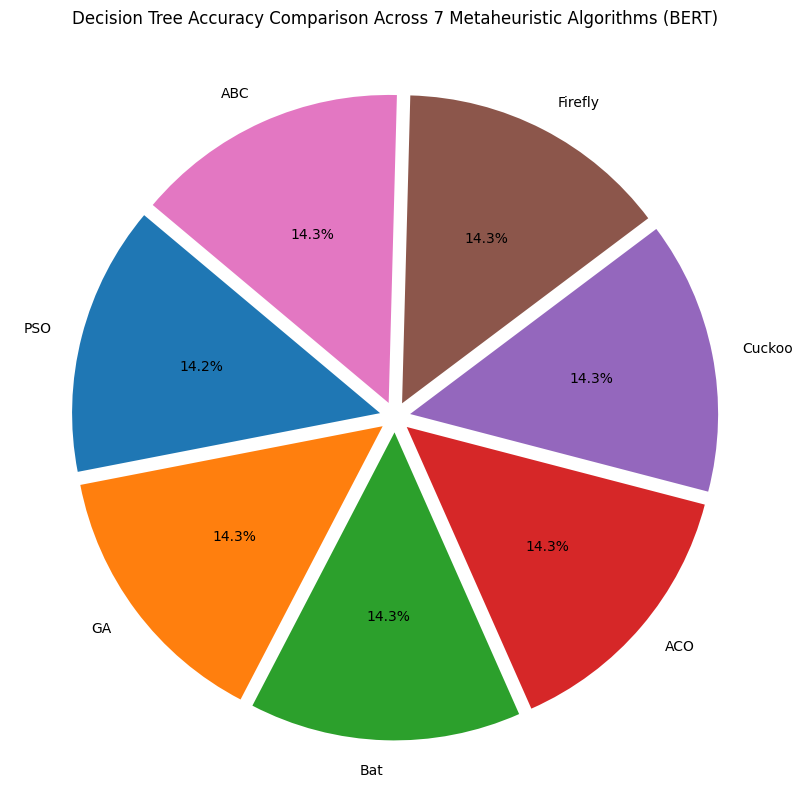

In [2]:


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import warnings
import torch
from transformers import BertTokenizer, BertModel
import os


from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')



def load_data_with_bert(cache_X="bert_base_embeddings.npy", cache_y="bert_base_labels.npy"):
    # GPU or CPU setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f" Using device: {device}")

    # ----------------------------

    # ----------------------------
    if os.path.exists(cache_X) and os.path.exists(cache_y):
        print(" Loading cached BERT embeddings from disk...")
        X = np.load(cache_X)
        y = np.load(cache_y)
    else:
        print("🔄 Generating new BERT embeddings (first run)...")

        # Load datasets
        amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
        imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
        yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
        df = pd.concat([amazon, imdb, yelp], axis=0).reset_index(drop=True)

        # Load BERT tokenizer and model
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        model = BertModel.from_pretrained('bert-base-uncased').to(device)

        def get_bert_embeddings(texts, batch_size=16):
            embeddings = []
            model.eval()
            with torch.no_grad():
                for i in range(0, len(texts), batch_size):
                    batch = texts[i:i+batch_size]
                    encoded = tokenizer(
                        batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt'
                    ).to(device)

                    outputs = model(**encoded)
                    # Mean pooling over the sequence dimension (same approach as DistilBERT version)
                    batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu()
                    embeddings.append(batch_embeddings)
            return torch.cat(embeddings).numpy()

        print("⚙️ Computing embeddings using BERT (this may take several minutes on CPU)...")
        X = get_bert_embeddings(df["text"].tolist())
        y = df["label"].values

        # Save for next time
        np.save(cache_X, X)
        np.save(cache_y, y)
        print(f"💾 Saved embeddings → {cache_X}, {cache_y}")

    print(" BERT embeddings ready!")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test



X_train, X_test, y_train, y_test = load_data_with_bert()



def dt_objective_function(solution):
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])
    min_samples_leaf = int(solution[2])
    criterion_idx = int(solution[3])
    criterion = 'gini' if criterion_idx == 0 else 'entropy'

    try:
        dt = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth if max_depth > 0 else None,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
        fitness = -np.mean(scores)  # Negative because Mealpy minimizes
    except:
        fitness = 1.0
    return fitness



dt_problem = {
    "bounds": [
        FloatVar(lb=2, ub=30, name="max_depth"),
        FloatVar(lb=2, ub=10, name="min_samples_split"),
        FloatVar(lb=1, ub=5, name="min_samples_leaf"),
        FloatVar(lb=0, ub=1, name="criterion")   # 0=gini, 1=entropy
    ],
    "minmax": "min",
    "obj_func": dt_objective_function
}



algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}
best_params_dict = {}

for name, optimizer in algorithms.items():
    print(f"\n Optimizing Decision Tree using {name}...")
    best_agent = optimizer.solve(dt_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness  # convert back to positive accuracy

    criterion = 'gini' if int(best_solution[3]) == 0 else 'entropy'
    best_params = {
        'max_depth': int(best_solution[0]),
        'min_samples_split': int(best_solution[1]),
        'min_samples_leaf': int(best_solution[2]),
        'criterion': criterion
    }

    results[name] = best_fitness
    best_params_dict[name] = best_params

    print(f"✅ {name} Accuracy: {best_fitness:.4f}")
    print(f"🏆 {name} Best Params: {best_params}\n")






plt.figure(figsize=(10, 10))
plt.pie(
    results.values(), labels=results.keys(),
    autopct='%1.1f%%', startangle=140,
    explode=[0.05]*len(results)
)
plt.title("Decision Tree Accuracy Comparison Across 7 Metaheuristic Algorithms (BERT)")
plt.show()


In [ ]:


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import warnings
import torch
from transformers import BertTokenizer, BertModel
import os


from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')



def load_data_with_bert(cache_X="bert_base_embeddings.npy", cache_y="bert_base_labels.npy"):
    # GPU or CPU setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f" Using device: {device}")

    # ----------------------------

    # ----------------------------
    if os.path.exists(cache_X) and os.path.exists(cache_y):
        print(" Loading cached BERT embeddings from disk...")
        X = np.load(cache_X)
        y = np.load(cache_y)
    else:
        print("🔄 Generating new BERT embeddings (first run)...")

        # Load datasets
        amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
        imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
        yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
        df = pd.concat([amazon, imdb, yelp], axis=0).reset_index(drop=True)

        # Load BERT tokenizer and model
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        model = BertModel.from_pretrained('bert-base-uncased').to(device)

        def get_bert_embeddings(texts, batch_size=16):
            embeddings = []
            model.eval()
            with torch.no_grad():
                for i in range(0, len(texts), batch_size):
                    batch = texts[i:i+batch_size]
                    encoded = tokenizer(
                        batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt'
                    ).to(device)

                    outputs = model(**encoded)
                    # Mean pooling over the sequence dimension (same approach as DistilBERT version)
                    batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu()
                    embeddings.append(batch_embeddings)
            return torch.cat(embeddings).numpy()

        print("⚙️ Computing embeddings using BERT (this may take several minutes on CPU)...")
        X = get_bert_embeddings(df["text"].tolist())
        y = df["label"].values

        # Save for next time
        np.save(cache_X, X)
        np.save(cache_y, y)
        print(f"💾 Saved embeddings → {cache_X}, {cache_y}")

    print(" BERT embeddings ready!")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test



X_train, X_test, y_train, y_test = load_data_with_bert()



def dt_objective_function(solution):
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])
    min_samples_leaf = int(solution[2])
    criterion_idx = int(solution[3])
    criterion = 'gini' if criterion_idx == 0 else 'entropy'

    try:
        dt = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth if max_depth > 0 else None,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
        fitness = -np.mean(scores)  # Negative because Mealpy minimizes
    except:
        fitness = 1.0
    return fitness



dt_problem = {
    "bounds": [
        FloatVar(lb=2, ub=30, name="max_depth"),
        FloatVar(lb=2, ub=10, name="min_samples_split"),
        FloatVar(lb=1, ub=5, name="min_samples_leaf"),
        FloatVar(lb=0, ub=1, name="criterion")   # 0=gini, 1=entropy
    ],
    "minmax": "min",
    "obj_func": dt_objective_function
}



algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}
best_params_dict = {}

for name, optimizer in algorithms.items():
    print(f"\n Optimizing Decision Tree using {name}...")
    best_agent = optimizer.solve(dt_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness  # convert back to positive accuracy

    criterion = 'gini' if int(best_solution[3]) == 0 else 'entropy'
    best_params = {
        'max_depth': int(best_solution[0]),
        'min_samples_split': int(best_solution[1]),
        'min_samples_leaf': int(best_solution[2]),
        'criterion': criterion
    }

    results[name] = best_fitness
    best_params_dict[name] = best_params

    print(f"✅ {name} Accuracy: {best_fitness:.4f}")
    print(f"🏆 {name} Best Params: {best_params}\n")






plt.figure(figsize=(10, 10))
plt.pie(
    results.values(), labels=results.keys(),
    autopct='%1.1f%%', startangle=140,
    explode=[0.05]*len(results)
)
plt.title("Decision Tree Accuracy Comparison Across 7 Metaheuristic Algorithms (BERT)")
plt.show()


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/10/10 09:47:31 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


 Using device: cpu
 Loading cached BERT embeddings from disk...
 BERT embeddings ready!

 Optimizing Decision Tree using PSO...


2025/10/10 09:48:26 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.726113707919894, Global best: -0.726113707919894, Runtime: 13.47621 seconds
2025/10/10 09:48:37 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.726113707919894, Global best: -0.726113707919894, Runtime: 11.03472 seconds
2025/10/10 09:48:47 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.726113707919894, Global best: -0.726113707919894, Runtime: 10.48855 seconds
